   region  tenure  age  marital  address  income  ed  employ  retire  gender  \
0       2      13   44        1        9    64.0   4       5     0.0       0   
1       3      11   33        1        7   136.0   5       5     0.0       0   
2       3      68   52        1       24   116.0   1      29     0.0       1   
3       2      33   33        0       12    33.0   2       0     0.0       1   
4       2      23   30        1        9    30.0   1       2     0.0       0   

   ...  voice  pager  internet  callid  callwait  forward  confer  ebill  \
0  ...      0      0         0       0         0        1       0      0   
1  ...      1      1         0       1         1        1       1      0   
2  ...      0      0         0       1         1        0       1      0   
3  ...      0      0         0       0         0        0       0      0   
4  ...      0      0         0       1         0        1       1      0   

   custcat  churn  
0        1      1  
1        4      1  
2 

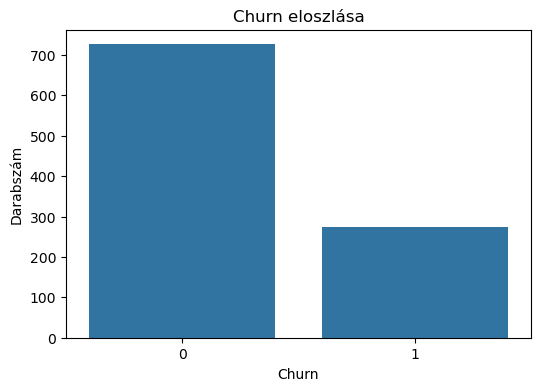

longmon: eltávolítva 66 sor
tollmon: eltávolítva 8 sor
equipmon: eltávolítva 0 sor
cardmon: eltávolítva 17 sor
wiremon: eltávolítva 22 sor


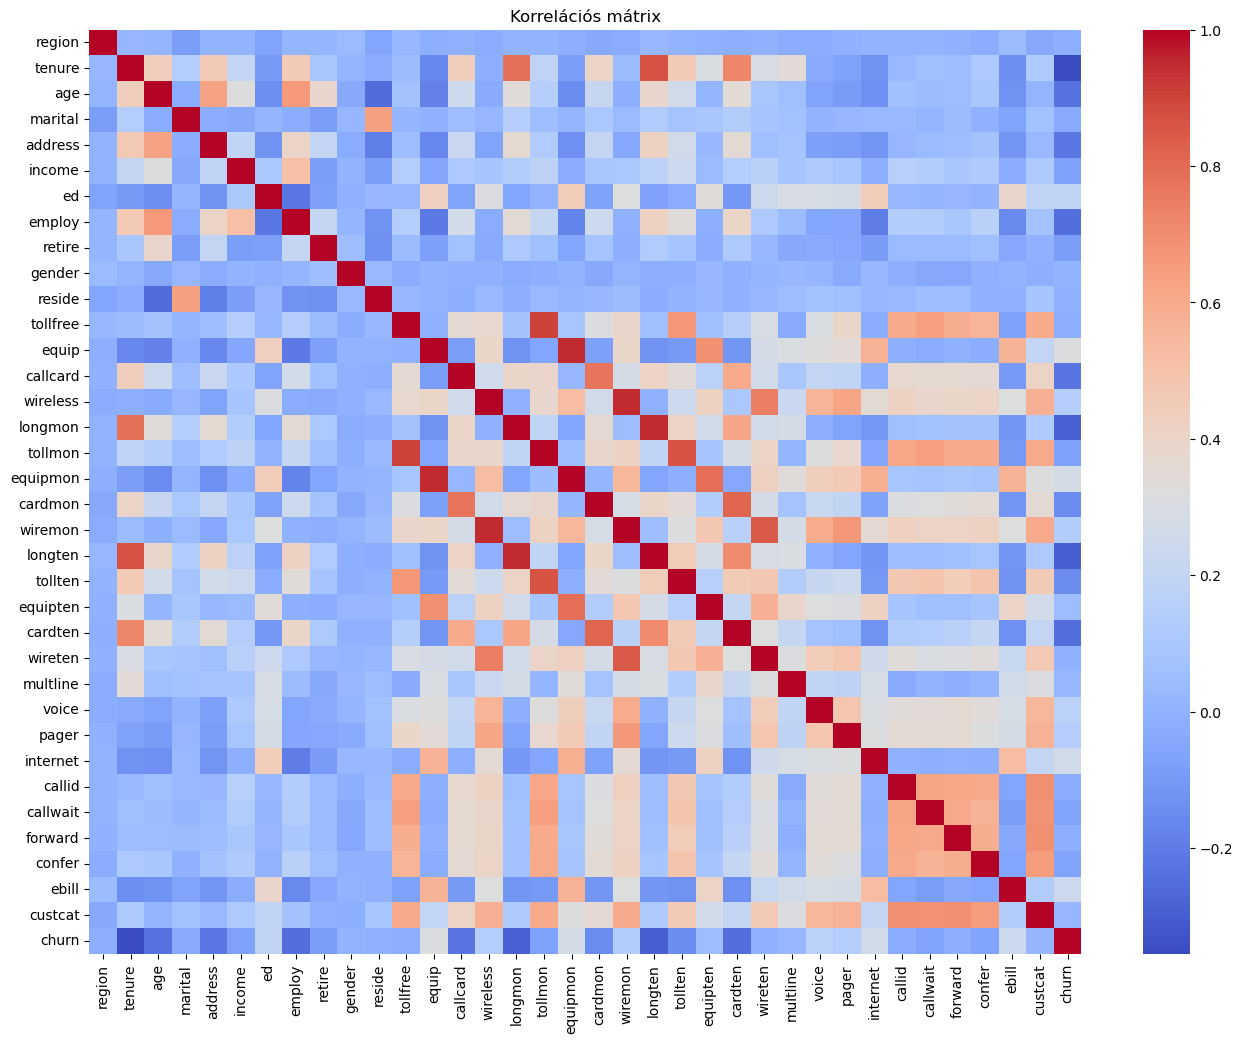


Erősen korreláló változók:
['tollmon', 'equipmon', 'wiremon', 'longten']

Tanuló halmaz:
(665, 31)

Tesztelő halmaz:
(222, 31)
DÖNTÉSI FA
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       157
           1       0.41      0.38      0.40        65

    accuracy                           0.66       222
   macro avg       0.58      0.58      0.58       222
weighted avg       0.65      0.66      0.65       222



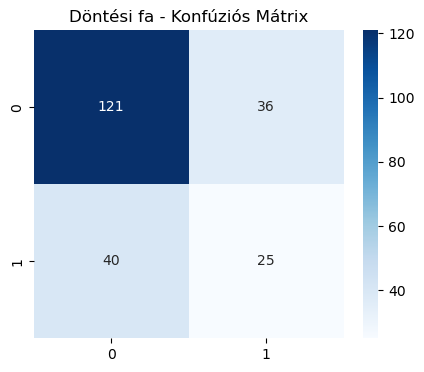

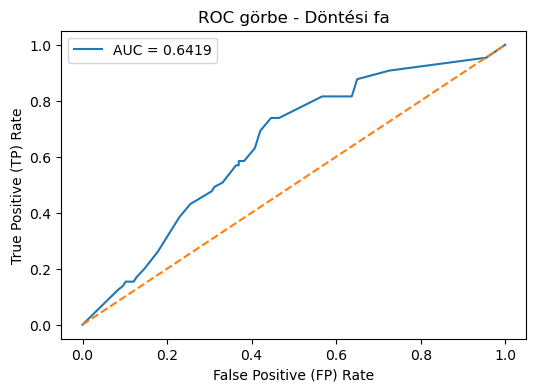

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       157
           1       0.55      0.40      0.46        65

    accuracy                           0.73       222
   macro avg       0.67      0.63      0.64       222
weighted avg       0.71      0.73      0.72       222



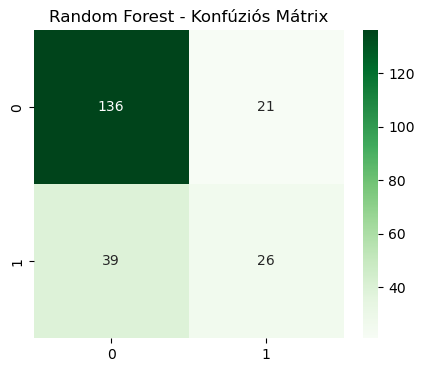

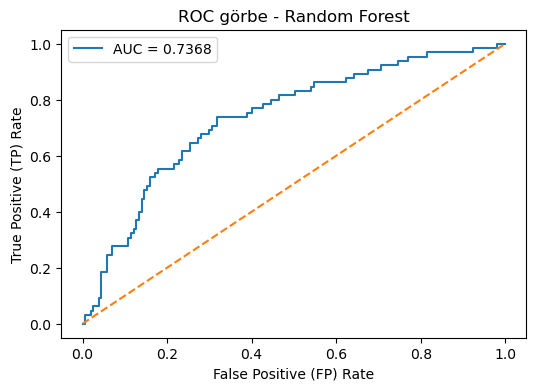

GBM
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       157
           1       0.50      0.40      0.44        65

    accuracy                           0.71       222
   macro avg       0.64      0.62      0.62       222
weighted avg       0.69      0.71      0.70       222



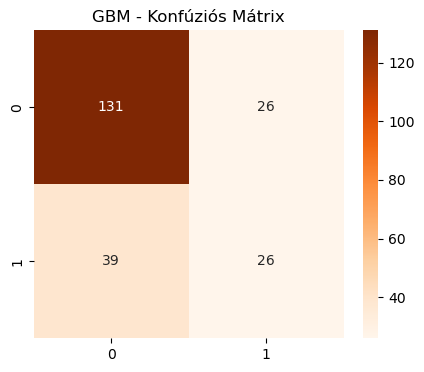

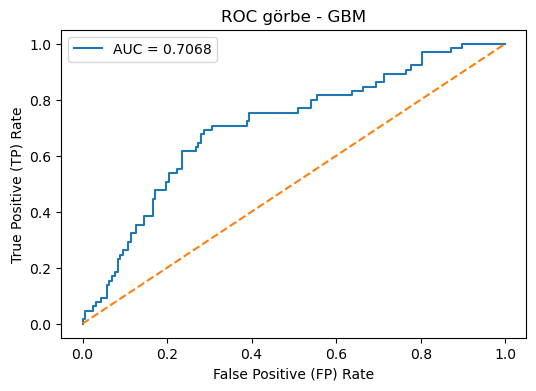

NEURÁLIS HÁLÓ
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       157
           1       0.38      0.34      0.36        65

    accuracy                           0.64       222
   macro avg       0.56      0.55      0.56       222
weighted avg       0.63      0.64      0.64       222



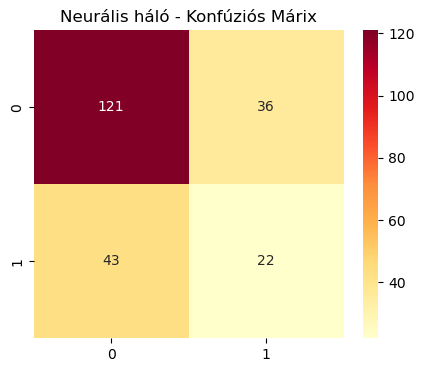

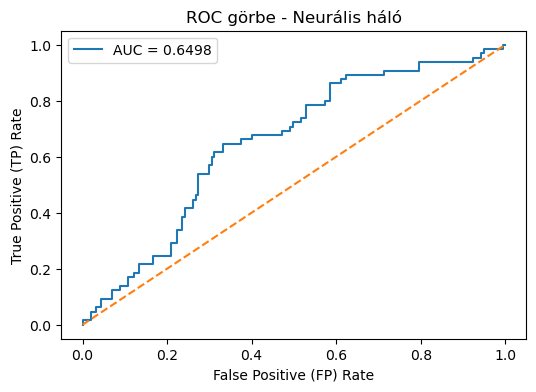

Modellek összehasonlítása
          Modell  Accuracy  Recall     AUC
1  Random Forest    0.7297  0.4000  0.7368
2            GBM    0.7072  0.4000  0.7068
3  Neurális háló    0.6441  0.3385  0.6498
4     Döntési fa    0.6577  0.3846  0.6419

Legjobb modell:
Random Forest
Első 10 ügyfél churn valószínűsége
     Valós_churn  Churn_valószínűség
219            0            0.811055
508            1            0.787063
658            1            0.780904
435            0            0.754898
696            0            0.726749
520            1            0.716911
649            0            0.713939
428            1            0.713476
141            0            0.708508
333            0            0.691768


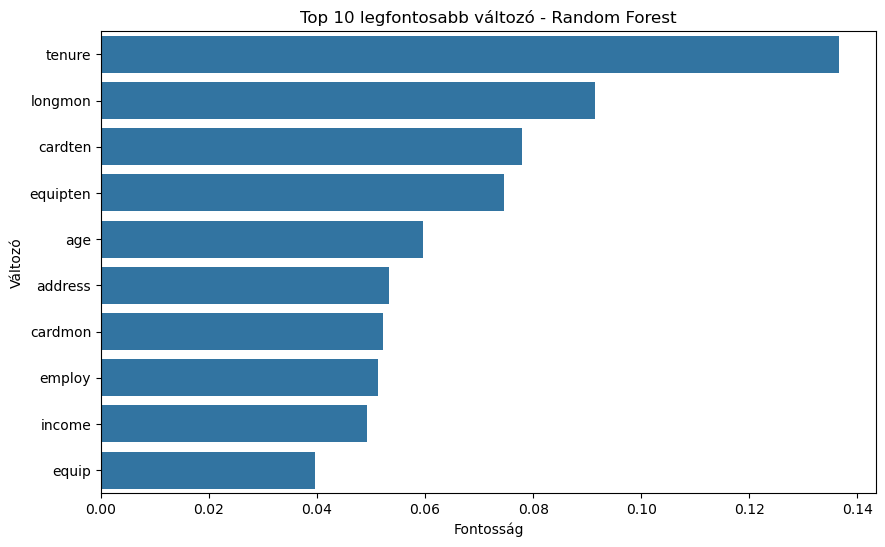

In [4]:
# 1. Könyvtárak

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
# 2. Adatok betöltése

df = pd.read_csv('telco.csv')
# Első sorok megtekintése
print(df.head())
# Méret
print("\nAdathalmaz mérete:")
print(df.shape)
# Információk
print("\nAdatok információi:")
print(df.info())
# Statisztikai leírás
print("\nLeíró statisztika:")
print(df.describe())

In [ ]:
# 3. Adattisztítás

# Oszlopnevek egységesítése
df.columns = df.columns.str.strip().str.lower()
# Hiányzó értékek egységesítése
df = df.replace(['?', 'NA', 'N/A', '', ' ', 'Nincs'], np.nan)
# Duplikációk vizsgálata
print("\nDuplikált sorok száma:")
print(df.duplicated().sum())
# Duplikált sorok törlése
df = df.drop_duplicates()
print("\nDuplikációk törlése után:")
print(df.shape)
# Célváltozó kezelése
df['churn'] = df['churn'].astype(str).str.lower().str.strip()
df['churn'] = df['churn'].map({
    'yes': 1,
    'no': 0,
    '1': 1,
    '0': 0
})
# Típuskonverzió
for col in df.columns:
    if col != 'churn':
        numericTry = pd.to_numeric(df[col], errors='coerce')
        if numericTry.notna().sum() > len(df) * 0.8:
            df[col] = numericTry
# Hiányzó értékek kezelése
# Numerikus oszlopok
numCols = df.select_dtypes(include=np.number).columns.tolist()
# Kategorikus oszlopok
catCols = df.select_dtypes(include='object').columns.tolist()
# Numerikus változók -> medián
for col in numCols:
    df[col] = df[col].fillna(df[col].median())
# Kategorikus változók -> módusz
for col in catCols:
    df[col] = df[col].fillna(df[col].mode()[0])
# Churn eloszlás
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title('Churn eloszlása')
plt.xlabel('Churn')
plt.ylabel('Darabszám')
plt.show()

In [ ]:
# 4. Outlier szűrés – IQR MÓDSZER

# Csak folytonos numerikus változókra
iqrCols = [
    'longmon',
    'tollmon',
    'equipmon',
    'cardmon',
    'wiremon'
]
# Csak létező oszlopokat használjuk fel
iqrCols = [col for col in iqrCols if col in df.columns]
for col in iqrCols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    also = Q1 - 1.5 * IQR
    felso = Q3 + 1.5 * IQR
    elotte = df.shape[0]
    df = df[
        (df[col] >= also) &
        (df[col] <= felso)
    ]
    utana = df.shape[0]
    print(f'{col}: eltávolítva {elotte - utana} sor')
# Index reset
df = df.reset_index(drop=True)

In [ ]:
# 5. Kategóriaváltozók átalakítása

df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

In [ ]:
# 6. Korreláció vizsgálata

# Korrelációs mátrix
corrMatrix = df.corr()
# Heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corrMatrix,
    cmap='coolwarm'
)
plt.title('Korrelációs mátrix')
plt.show()
# Túl erősen korreláló változók törlése
upper = corrMatrix.where(
    np.triu(np.ones(corrMatrix.shape), k=1).astype(bool)
)
highCorr = [
    column for column in upper.columns
    if any(abs(upper[column]) > 0.90)
]
print("\nErősen korreláló változók:")
print(highCorr)
# Törlés
df = df.drop(columns=highCorr)

In [ ]:
# 7. Független és célváltozók

X = df.drop('churn', axis=1)
y = df['churn']

In [ ]:
# 8. Tanuló és tesztelő halmaz

XTrain, XTest, yTrain, yTest = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print("\nTanuló halmaz:")
print(XTrain.shape)
print("\nTesztelő halmaz:")
print(XTest.shape)

In [ ]:
# 9. Standardizálás

scaler = StandardScaler()
XTrainSc = scaler.fit_transform(XTrain)
XTestSc = scaler.transform(XTest)

In [ ]:
# 10. Modellek definiálása

# Döntési fa
dtModel = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)
# Véletlen erdő
rfModel = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
# Gradient Boosting
gbmModel = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=200,
    max_depth=3,
    random_state=42
)
# Neurális háló
nnModel = MLPClassifier(
    hidden_layer_sizes=(100,50),
    max_iter=1000,
    random_state=42
)

In [ ]:
# 11. Modellek illesztése

# Tree modellek
dtModel.fit(XTrain, yTrain)
rfModel.fit(XTrain, yTrain)
gbmModel.fit(XTrain, yTrain)
# Neurális háló
nnModel.fit(XTrainSc, yTrain)

In [ ]:
# 12. Predikciók

# Tree modellek
dtPred = dtModel.predict(XTest)
dtProb = dtModel.predict_proba(XTest)[:,1]
rfPred = rfModel.predict(XTest)
rfProb = rfModel.predict_proba(XTest)[:,1]
# GBM
gbmPred = gbmModel.predict(XTest)
gbmProb = gbmModel.predict_proba(XTest)[:,1]
# Neurális háló
nnPred = nnModel.predict(XTestSc)
nnProb = nnModel.predict_proba(XTestSc)[:,1]

In [ ]:
# 13. Modellek kiértékelése (Fák)

eredmenyek = []
# Döntési fa
dtAccuracy = accuracy_score(yTest, dtPred)
dtRecall = recall_score(yTest, dtPred)
dtAuc = roc_auc_score(yTest, dtProb)
print("DÖNTÉSI FA")
print(classification_report(yTest, dtPred))
eredmenyek.append({
    'Modell': 'Döntési fa',
    'Accuracy': round(dtAccuracy, 4),
    'Recall': round(dtRecall, 4),
    'AUC': round(dtAuc, 4)
})
# Konfúziós mátrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(yTest, dtPred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Döntési fa - Konfúziós Mátrix')
plt.show()
# ROC görbe
fpr, tpr, _ = roc_curve(yTest, dtProb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {dtAuc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC görbe - Döntési fa')
plt.xlabel('False Positive (FP) Rate')
plt.ylabel('True Positive (TP) Rate')
plt.legend()
plt.show()
# Random forest
rfAccuracy = accuracy_score(yTest, rfPred)
rfRecall = recall_score(yTest, rfPred)
rfAuc = roc_auc_score(yTest, rfProb)
print("RANDOM FOREST")
print(classification_report(yTest, rfPred))
eredmenyek.append({
    'Modell': 'Random Forest',
    'Accuracy': round(rfAccuracy, 4),
    'Recall': round(rfRecall, 4),
    'AUC': round(rfAuc, 4)
})
# Konfúziós mátrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(yTest, rfPred),
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title('Random Forest - Konfúziós Mátrix')
plt.show()
# ROC görbe
fpr, tpr, _ = roc_curve(yTest, rfProb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {rfAuc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC görbe - Random Forest')
plt.xlabel('False Positive (FP) Rate')
plt.ylabel('True Positive (TP) Rate')
plt.legend()
plt.show()

In [ ]:
# 14. Modellek kiértékelése (Többi)

gbmAccuracy = accuracy_score(yTest, gbmPred)
gbmRecall = recall_score(yTest, gbmPred)
gbmAuc = roc_auc_score(yTest, gbmProb)
print("GBM")
print(classification_report(yTest, gbmPred))
eredmenyek.append({
    'Modell': 'GBM',
    'Accuracy': round(gbmAccuracy, 4),
    'Recall': round(gbmRecall, 4),
    'AUC': round(gbmAuc, 4)
})
# Konfúziós mátrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(yTest, gbmPred),
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.title('GBM - Konfúziós Mátrix')
plt.show()
# ROC görbe
fpr, tpr, _ = roc_curve(yTest, gbmProb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {gbmAuc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC görbe - GBM')
plt.xlabel('False Positive (FP) Rate')
plt.ylabel('True Positive (TP) Rate')
plt.legend()
plt.show()
# Neurális háló
nnAccuracy = accuracy_score(yTest, nnPred)
nnRecall = recall_score(yTest, nnPred)
nnAuc = roc_auc_score(yTest, nnProb)
print("NEURÁLIS HÁLÓ")
print(classification_report(yTest, nnPred))
eredmenyek.append({
    'Modell': 'Neurális háló',
    'Accuracy': round(nnAccuracy, 4),
    'Recall': round(nnRecall, 4),
    'AUC': round(nnAuc, 4)
})
# Konfúziós mátrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(yTest, nnPred),
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)
plt.title('Neurális háló - Konfúziós Márix')
plt.show()
# ROC görbe
fpr, tpr, _ = roc_curve(yTest, nnProb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {nnAuc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC görbe - Neurális háló')
plt.xlabel('False Positive (FP) Rate')
plt.ylabel('True Positive (TP) Rate')
plt.legend()
plt.show()

In [ ]:
# 15. Modellek összehasonlítása

eredmenyDf = pd.DataFrame(eredmenyek)
eredmenyDf = eredmenyDf.sort_values(
    'AUC',
    ascending=False
).reset_index(drop=True)
eredmenyDf.index += 1
# Modell összehasonlítás
print("Modellek összehasonlítása")
print(eredmenyDf)

In [ ]:
# 16. Legjobb modell kiválasztása

legjobbModellNev = eredmenyDf.iloc[0]['Modell']
print("\nLegjobb modell:")
print(legjobbModellNev)

In [ ]:
# 17. Churn valószínűségek

if legjobbModellNev == 'Döntési fa':
    legjobbProb = dtProb
elif legjobbModellNev == 'Random Forest':
    legjobbProb = rfProb
elif legjobbModellNev == 'GBM':
    legjobbProb = gbmProb
else:
    legjobbProb = nnProb
# Valószínűségek dataframe-be
probDf = XTest.copy()
probDf['Valós_churn'] = yTest.values
probDf['Churn_valószínűség'] = legjobbProb
# Sorbarendezés
probDf = probDf.sort_values(
    'Churn_valószínűség',
    ascending=False
)
print("Első 10 ügyfél churn valószínűsége")
print(
    probDf[
        ['Valós_churn', 'Churn_valószínűség']
    ].head(10)
)

In [ ]:
# 18. Legfontosabb változók

featureImportance = pd.DataFrame({
    'Változó': X.columns,
    'Fontosság': rfModel.feature_importances_
})
featureImportance = featureImportance.sort_values(
    'Fontosság',
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    data=featureImportance,
    x='Fontosság',
    y='Változó'
)
plt.title('Top 10 legfontosabb változó - Random Forest')
plt.show()